In [ ]:
#| default_exp utils.diagrams

In [ ]:
#| hide
from pathlib import Path
import subprocess

def render_d2_cli(
    diagram_str: str,
    output_path: Path,
    theme: int = 0,
    sketch: bool = True,
    pad: int = 10,
    scale: float = 1.5,
    layout: str = "dagre",
    keep_source: bool = True
) -> bool:
    """
    Render d2 diagram using CLI (deterministic, no browser required).
    
    Parameters
    ----------
    diagram_str : str
        D2 DSL definition.
    output_path : Path
        Where to save SVG (parent dirs created automatically).
    theme : int
        D2 theme ID (0=Neutral, 1=Flagship Terrastruct, ...).
    sketch : bool
        Enable hand-drawn style.
    pad : int
        Padding around diagram (pixels).
    scale : float
        Zoom multiplier.
    layout : str
        Layout engine: 'dagre' (default), 'elk', 'tala'.
    keep_source : bool
        If True, preserve .d2 source file alongside .svg output.
    
    Returns
    -------
    bool
        True if render succeeded; False if d2 CLI not found or render failed.
    
    Examples
    --------
    >>> diagram = "A -> B: label"
    >>> render_d2_cli(diagram, Path('diagrams/flow.svg'))
    True
    
    Notes
    -----
    - d2 requires a file path (no stdin support), so we write .d2 to disk.
    - By default, .d2 source is preserved for version control and debugging.
    - d2 overwrites existing .svg files automatically (no --force flag).
    """
    # Check if d2 CLI is installed
    try:
        subprocess.run(['d2', '--version'], capture_output=True, check=True, text=True)
    except (subprocess.CalledProcessError, FileNotFoundError):
        print("⚠ d2 CLI not found. Install: https://d2lang.com/tour/install")
        return False
    if not isinstance(output_path, Path):
        output_path = Path(output_path)

    # Write .d2 source alongside .svg output (not a temp file)
    d2_source_path = output_path.with_suffix('.d2')
    d2_source_path.write_text(diagram_str)
    
    # Build d2 command
    cmd = [
        'd2',
        '--theme', str(theme),
        '--pad', str(pad),
        '--scale', str(scale),
        '--layout', layout,
    ]
    if sketch:
        cmd.append('--sketch')
    cmd.extend([str(d2_source_path), str(output_path)])
    
    # Run d2
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"✗ d2 failed: {result.stderr}")
        print(f"  Source preserved for debugging: {d2_source_path}")
        return False
    
    # Optionally clean up .d2 source on success
    if not keep_source:
        d2_source_path.unlink()
    
    print(f"✓ Saved: {output_path} ({output_path.stat().st_size} bytes)")
    if keep_source:
        print(f"  Source: {d2_source_path}")
    
    return True

In [ ]:
# In nbs/utils_d2_diagrams.ipynb or a separate "generate_diagrams.ipynb"
from pathlib import Path

# Sidecar diagram
sidecar_diagram = """
direction: right

# 1. INITIAL DATA
Observations: {
  shape: sql_table
  style: {fill: "#f8cecc"}
  source_id:  "value | geometry"
  "src_1   ": "10000 | POLY(..)"
  "src_2   ": "20000 | POLY(..)"
  "src_3   ": "30000 | POLY(..)"
}

# 2. SIDECAR
Sidecar: {
  shape: sql_table
  style: {fill: "#dae8fc"}
  index: "source id | healpix id"
  "1": "src_1 | h_pix_A"
  "3": "src_2 | h_pix_A"
  "4": "src_3 | h_pix_B"
}

# 3. AGGREGATED + GEOMETRY
Healpix Target Grid: {
  shape: sql_table
  style: {fill: "#d5e8d4"}
  index: "healpix id"
  "1": "h_pix_A"
  "2": "h_pix_B"
}

# PROCESS FLOW
Observations <-> Sidecar: "healpyxel_sidecar\\n(Assign: strict/fuzzy)" {style: {stroke-width: 2}}
Sidecar <-> Healpix Target Grid: nside=32
"""
render_d2_cli(sidecar_diagram,'Sidecar.svg')

# Aggregate diagram
aggregate_diagram = """
direction: right

# INPUTS
Observations: {
  shape: sql_table
  style: {fill: "#f8cecc"}
  source_id:  "value | geometry"
  "src_1   ": "10000 | POLY(..)"
  "src_2   ": "20000 | POLY(..)"
  "src_3   ": "30000 | POLY(..)"
}


Sidecar: {
  shape: sql_table
  style: {fill: "#dae8fc"}
  source_id: "healpix_id"
  "src_1": "pix_A"
  "src_2": "pix_A"
  "src_3": "pix_B"
}

# AGGREGATION FUNCTION
healpyxel_aggregate: {
  style: {fill: "#fff4e6"}
  "Median(value)"
}

# OUTPUT
Aggregated: {
  shape: sql_table
  style: {fill: "#d5e8d4"}
  healpix_id: "median| n_sources"
  "pix_A": "015000 | 0000002"
  "pix_B": "030000 | 0000001"
}

# FLOW
Observations -> healpyxel_aggregate #: "group by\\nhealpix_id"
Sidecar -> healpyxel_aggregate #: "via source_id"
healpyxel_aggregate -> Aggregated
"""

render_d2_cli(aggregate_diagram, 'Aggregate.svg')

# Combine diagram

combine_diagram = """
direction: right

# INPUT
Aggregated: {
  shape: sql_table
  style: {fill: "#d5e8d4"}
  healpix_id: "median | n_sources"
  "pix_A": "015000 | 00000002"
  "pix_B": "030000 | 00000001"
}

# GEOMETRY ATTACHMENT
healpyxel_to_geoparquet: {
  style: {fill: "#fff4e6"}
  "HEALPix Cell Geometry\\nvia healpy"
}

# OUTPUT
Aggregated_Geo: {
  shape: sql_table
  style: {fill: "#e1d5e7"}
  healpix_id: "median | n_sources | geometry"
  "pix_A":    "015000 | 00000002 | POLY(..)"
  "pix_B":    "030000 | 00000001 | POLY(..)"
}

# FLOW
Aggregated -> healpyxel_to_geoparquet
healpyxel_to_geoparquet -> Aggregated_Geo
"""

render_d2_cli(combine_diagram, 'Combine.svg')

✓ Saved: Sidecar.svg (94680 bytes)
  Source: Sidecar.d2
✓ Saved: Aggregate.svg (92382 bytes)
  Source: Aggregate.d2
✓ Saved: Combine.svg (87628 bytes)
  Source: Combine.d2


True

In [ ]:
#| hide
import geopandas as gpd
import matplotlib.pyplot as plt
import healpy as hp
from healpyxel.geospatial import healpix_to_geodataframe
import cartopy.crs as ccrs
import warnings

# Define projection and convert GeoDataFrame to it
# projection = ccrs.Orthographic(central_longitude=0, central_latitude=0)
projection = ccrs.Orthographic(central_longitude=0, central_latitude=0)

In [ ]:
#| hide
# Create complete HEALPix grid at nside=4
nside = 8
gdf = healpix_to_geodataframe(
    nside=nside,
    order='nested',
    lon_convention='0_360',
    fix_antimeridian=True,
    cache_mode='use'
)

# Verify we have all pixels
expected_npix = hp.nside2npix(nside)
assert len(gdf) == expected_npix, f"Expected {expected_npix} pixels, got {len(gdf)}"

print(f"Created GeoDataFrame with {len(gdf)} HEALPix cells (nside={nside})")
print(f"Columns: {list(gdf.columns)}")
print(f"Index name: {gdf.index.name}")
print(f"CRS: {gdf.crs}")

# Suppress expected warnings from projecting back-hemisphere geometries
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', 'invalid value encountered in normalize', RuntimeWarning)
    gdf_projected_8 = gdf.to_crs(projection.proj4_init)

# # Create visualization
# fig, ax = plt.subplots(figsize=(10, 10))

# # Plot with pixel IDs as colors
# gdf_projected_8.plot(
#     column=gdf.index,  # Color by healpix_id
#     cmap='Spectral_r',
#     legend=False,
#     edgecolor='black',
#     linewidth=0.8,
#     ax=ax
# )

# ax.set_title(f'HEALPix Grid - Orthographic View (nside={nside})', fontsize=14)
# ax.set_aspect('equal')
# ax.axis('off')  # Hide axis for cleaner sphere view
# plt.tight_layout()


# plt.savefig(f'healpix_grid_nside-{nside}_orthographic.png', dpi=100)

Created GeoDataFrame with 768 HEALPix cells (nside=8)
Columns: ['geometry']
Index name: healpix_id
CRS: EPSG:4326


In [ ]:
#| hide
# Create complete HEALPix grid at nside=4
nside = 16
gdf = healpix_to_geodataframe(
    nside=nside,
    order='nested',
    lon_convention='0_360',
    fix_antimeridian=True,
    cache_mode='use'
)

# Verify we have all pixels
expected_npix = hp.nside2npix(nside)
assert len(gdf) == expected_npix, f"Expected {expected_npix} pixels, got {len(gdf)}"

print(f"Created GeoDataFrame with {len(gdf)} HEALPix cells (nside={nside})")
print(f"Columns: {list(gdf.columns)}")
print(f"Index name: {gdf.index.name}")
print(f"CRS: {gdf.crs}")

# Suppress expected warnings from projecting back-hemisphere geometries
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', 'invalid value encountered in normalize', RuntimeWarning)
    gdf_projected_16 = gdf.to_crs(projection.proj4_init)

# # Create visualization
# fig, ax = plt.subplots(figsize=(10, 10))
#
# # Plot with pixel IDs as colors
# gdf_projected_16.plot(
#     column=gdf.index,  # Color by healpix_id
#     cmap='Spectral_r',
#     legend=False,
#     edgecolor='black',
#     linewidth=0.8,
#     ax=ax
# )

# ax.set_title(f'HEALPix Grid - Orthographic View (nside={nside})', fontsize=14)
# ax.set_aspect('equal')
# ax.axis('off')  # Hide axis for cleaner sphere view
# plt.tight_layout()

# plt.savefig(f'healpix_grid_nside-{nside}_orthographic.png', dpi=100)

Created GeoDataFrame with 3072 HEALPix cells (nside=16)
Columns: ['geometry']
Index name: healpix_id
CRS: EPSG:4326


In [ ]:
#| hide
# Create complete HEALPix grid at nside=4
nside = 32
gdf = healpix_to_geodataframe(
    nside=nside,
    order='nested',
    lon_convention='0_360',
    fix_antimeridian=True,
    cache_mode='use'
)

# Verify we have all pixels
expected_npix = hp.nside2npix(nside)
assert len(gdf) == expected_npix, f"Expected {expected_npix} pixels, got {len(gdf)}"

print(f"Created GeoDataFrame with {len(gdf)} HEALPix cells (nside={nside})")
print(f"Columns: {list(gdf.columns)}")
print(f"Index name: {gdf.index.name}")
print(f"CRS: {gdf.crs}")

# Suppress expected warnings from projecting back-hemisphere geometries
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', 'invalid value encountered in normalize', RuntimeWarning)
    gdf_projected_32 = gdf.to_crs(projection.proj4_init)

# # Create visualization
# fig, ax = plt.subplots(figsize=(10, 10))

# # Plot with pixel IDs as colors
# gdf_projected_32.plot(
#     column=gdf.index,  # Color by healpix_id
#     cmap='Spectral_r',
#     legend=False,
#     edgecolor='black',
#     linewidth=0.8,
#     ax=ax
# )

# ax.set_title(f'HEALPix Grid - Orthographic View (nside={nside})', fontsize=14)
# ax.set_aspect('equal')
# ax.axis('off')  # Hide axis for cleaner sphere view
# plt.tight_layout()


# plt.savefig(f'healpix_grid_nside-{nside}_orthographic.png', dpi=100)

Created GeoDataFrame with 12288 HEALPix cells (nside=32)
Columns: ['geometry']
Index name: healpix_id
CRS: EPSG:4326


/home/kidpixo/miniconda3/envs/mertis/lib/python3.11/site-packages/shapely/constructive.py:829: RuntimeWarning: invalid value encountered in normalize
  return lib.normalize(geometry, **kwargs)
/home/kidpixo/miniconda3/envs/mertis/lib/python3.11/site-packages/shapely/constructive.py:829: RuntimeWarning: invalid value encountered in normalize
  return lib.normalize(geometry, **kwargs)
/home/kidpixo/miniconda3/envs/mertis/lib/python3.11/site-packages/shapely/constructive.py:829: RuntimeWarning: invalid value encountered in normalize
  return lib.normalize(geometry, **kwargs)


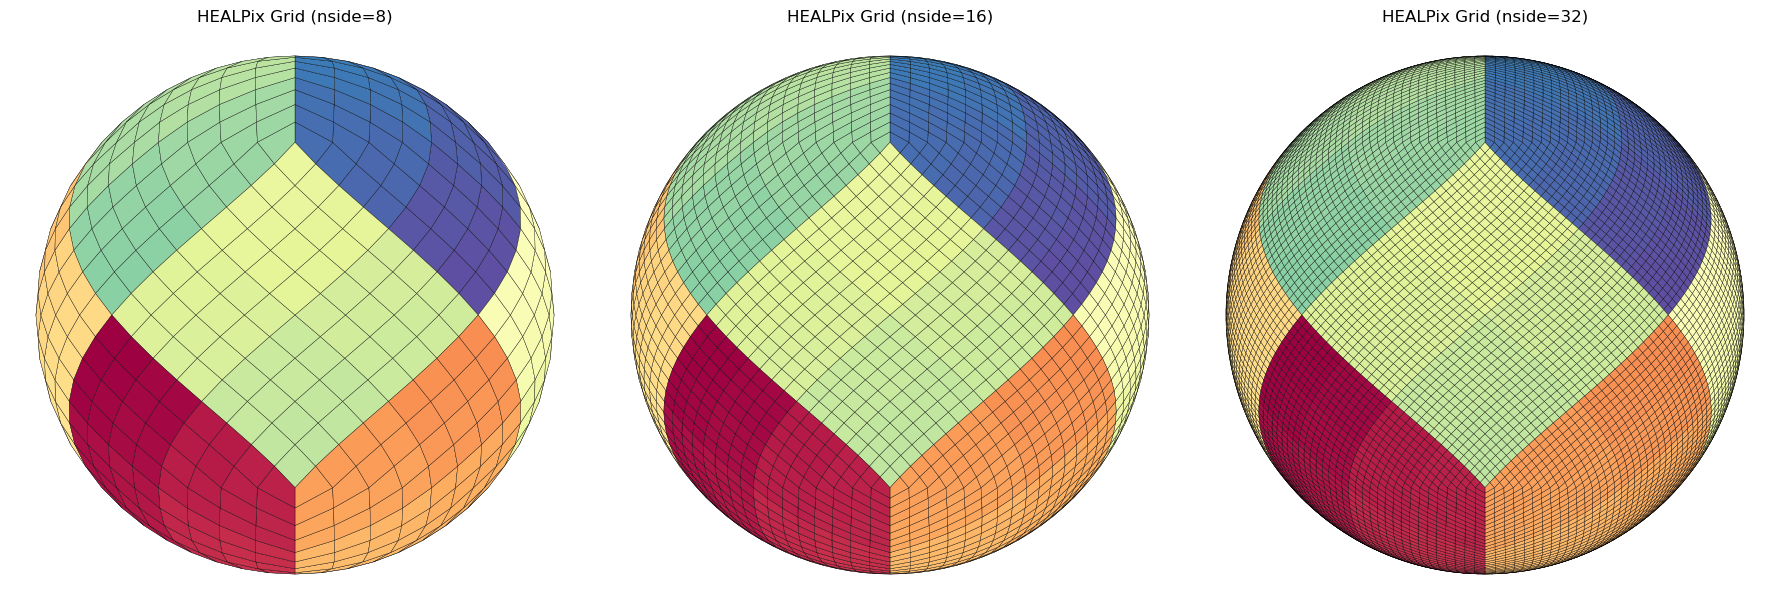

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_config = {
    'cmap':'Spectral_r',
    'legend':False,
    'edgecolor':'black',
    'linewidth':0.25,
}

# Plot nside=8
gdf_projected_8.plot(
    column=gdf_projected_8.index,
    ax=axes[0],
    **plot_config
)
axes[0].set_title('HEALPix Grid (nside=8)')
axes[0].set_aspect('equal')
axes[0].axis('off')

# Plot nside=16
gdf_projected_16.plot(
    column=gdf_projected_16.index,
    ax=axes[1],
    **plot_config,
)
axes[1].set_title('HEALPix Grid (nside=16)')
axes[1].set_aspect('equal')
axes[1].axis('off')

# Plot nside=32
gdf_projected_32.plot(
    column=gdf_projected_32.index,
    ax=axes[2],
    **plot_config
)
axes[2].set_title('HEALPix Grid (nside=32)')
axes[2].set_aspect('equal')
axes[2].axis('off')

plt.tight_layout()

plt.savefig('healpix_grids_comparison.png', dpi=100, bbox_inches='tight')